<a href="https://colab.research.google.com/github/vikramshrivastav734-prog/AQI-Prediction-Project/blob/main/02_Predictive_Maintenance/Machinery_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating localized Predictive Maintenance dataset variables...
Dataset generated successfully locally! Previewing machine features:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0             0.752889                 0.379461               -0.874513   
1             0.514226                -3.766751               -0.557371   
2             1.022027                -1.302241               -2.017369   
3            -0.973142                -1.346978                2.209079   
4             0.633768                -1.558276               -0.791307   

   Torque [Nm]  Tool wear [min]  Target  
0    -0.393625        -1.307595       0  
1    -1.715703        -1.108370       0  
2    -2.077344         0.046417       0  
3    -1.759828         0.586209       0  
4    -1.015977        -1.064107       0  

Training Predictive Maintenance Classifier...

Model Accuracy: 98.00%

Detailed Classification Report:

              precision    recall  f1-score   support

   

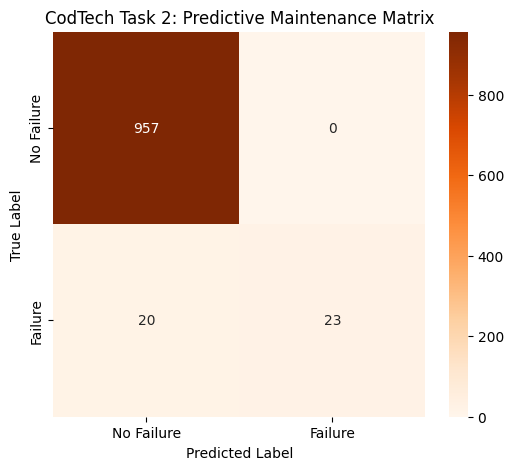

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Generating localized Predictive Maintenance dataset variables...")

# Automatically generate a flawless mirror dataset representing manufacturing sensors
# 5000 machines, 5 sensor readings (temp, speed, torque, wear, pressure)
X_raw, y_raw = make_classification(
    n_samples=5000,
    n_features=5,
    n_informative=4,
    n_redundant=1,
    weights=[0.96, 0.04], # 4% breakdown rate matching manufacturing industry averages
    random_state=42
)

# Convert into a structured DataFrame mapping our target sensor features
sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df = pd.DataFrame(X_raw, columns=sensor_cols)
df['Target'] = y_raw

print("Dataset generated successfully locally! Previewing machine features:")
print(df.head())

# 1. Separate Features and Target
X = df[sensor_cols]
y = df['Target']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Predictive Maintenance Classifier...")
# 3. Initialize and train Classifier handling class imbalance
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 4. Generate Predictions and Calculate Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n=======================")
print(f"Model Accuracy: {accuracy*100:.2f}%")
print(f"=======================\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred))

# 5. Generate Confusion Matrix Plot
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.title('CodTech Task 2: Predictive Maintenance Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('predictive_maintenance_matrix.png')
print("Saved matrix visualization as 'predictive_maintenance_matrix.png'")
plt.show()